In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving titanic-2.csv to titanic-2.csv


In [36]:
df = pd.read_csv('titanic-2.csv')
df

,name,gender,age,class,embarked,country,ticketno,fare,sibsp,parch,survived
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0.0,0.0,no
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0.0,2.0,no
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,1.0,1.0,no
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1.0,1.0,yes
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,0.0,0.0,yes
...,...,...,...,...,...,...,...,...,...,...,...
2202,"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,NaN,NaN,yes
2203,"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,NaN,NaN,yes
2204,"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,NaN,NaN,no
2205,"Zanetti, Sig. Minio",male,20.0,restaurant staff,S,England,NaN,NaN,NaN,NaN,no


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2207 entries, 0 to 2206
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      2207 non-null   object 
 1   gender    2207 non-null   object 
 2   age       2205 non-null   float64
 3   class     2207 non-null   object 
 4   embarked  2207 non-null   object 
 5   country   2126 non-null   object 
 6   ticketno  1316 non-null   float64
 7   fare      1291 non-null   float64
 8   sibsp     1307 non-null   float64
 9   parch     1307 non-null   float64
 10  survived  2207 non-null   object 
dtypes: float64(5), object(6)
memory usage: 189.8+ KB


In [8]:
df.shape

(2207, 11)

In [9]:
df.describe()

,age,ticketno,fare,sibsp,parch
count,2205.000000,1.316000e+03,1291.000000,1307.000000,1307.000000
mean,30.444444,2.842157e+05,33.404760,0.499617,0.385616
std,12.151764,6.334726e+05,52.227592,1.042273,0.866092
min,0.166667,2.000000e+00,3.030500,0.000000,0.000000
25%,22.000000,1.426225e+04,7.180600,0.000000,0.000000
50%,29.000000,1.114265e+05,14.090200,0.000000,0.000000
75%,38.000000,3.470770e+05,31.060750,1.000000,0.000000
max,74.000000,3.101317e+06,512.060700,8.000000,9.000000


In [10]:
df.isnull().sum()

,0
name,0
gender,0
age,2
class,0
embarked,0
country,81
ticketno,891
fare,916
sibsp,900
parch,900


In [38]:
# Fill missing 'age' with median
df['age'].fillna(df['age'].median(), inplace=True)

# Fill missing 'country' with 'Unknown'
df['country'].fillna('Unknown', inplace=True)

# Drop useless columns with too many missing values
df.drop(['ticketno', 'fare', 'sibsp', 'parch'], axis=1, inplace=True)

##Exploratory Data Analysis

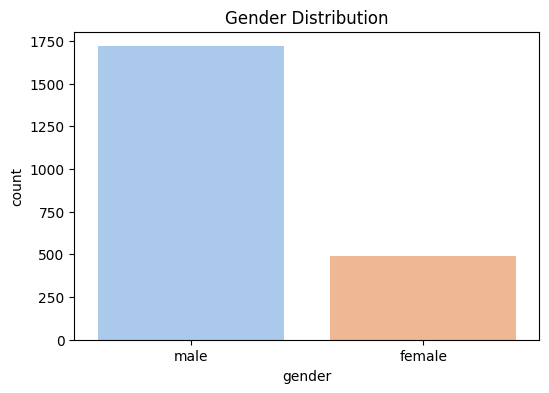

In [39]:
# Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender', palette='pastel')
plt.title('Gender Distribution')
plt.show()

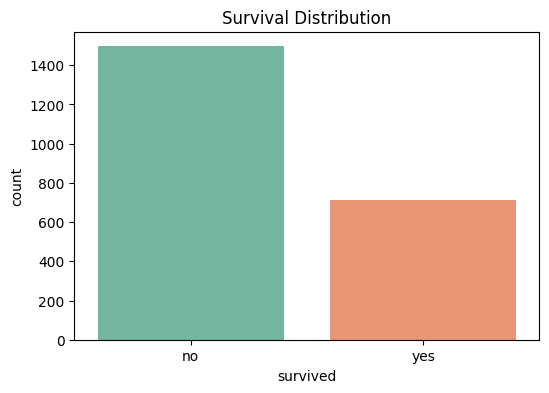

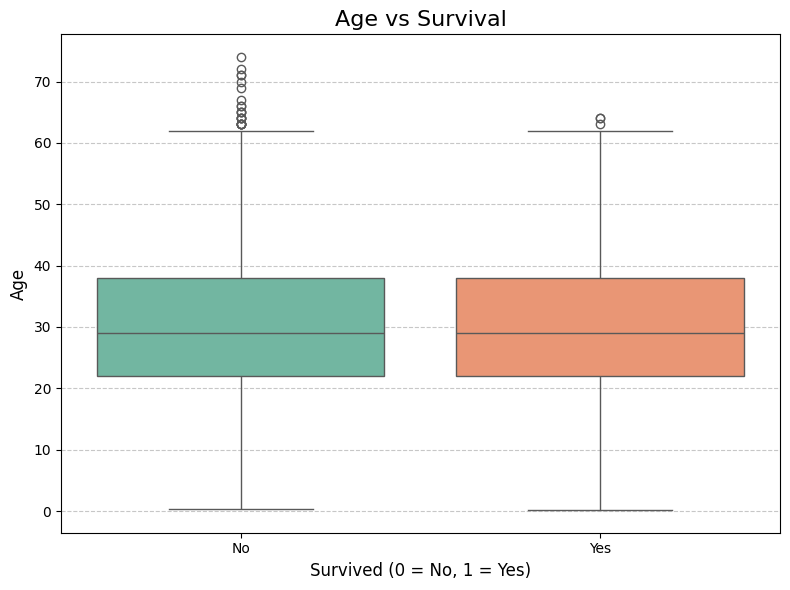

In [40]:
# Survival distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='survived', palette='Set2')
plt.title('Survival Distribution')
plt.show()
# Age vs Survival
plt.figure(figsize=(8,6))
sns.boxplot(x='survived', y='age', data=df, palette='Set2')

plt.title('Age vs Survival', fontsize=16)
plt.xlabel('Survived (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.xticks([0,1], ['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


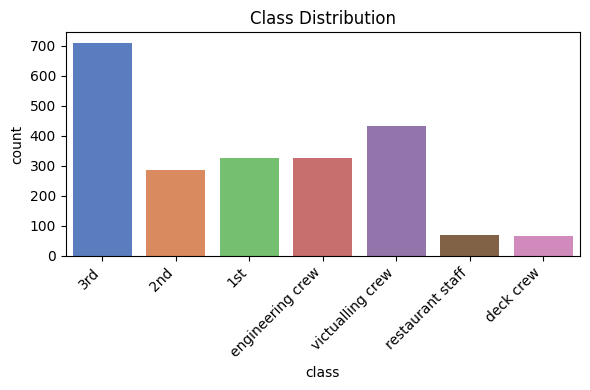

In [44]:
# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='class', palette='muted')
plt.xticks(rotation=45, ha='right')  # Rotate x-labels for better visibility
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

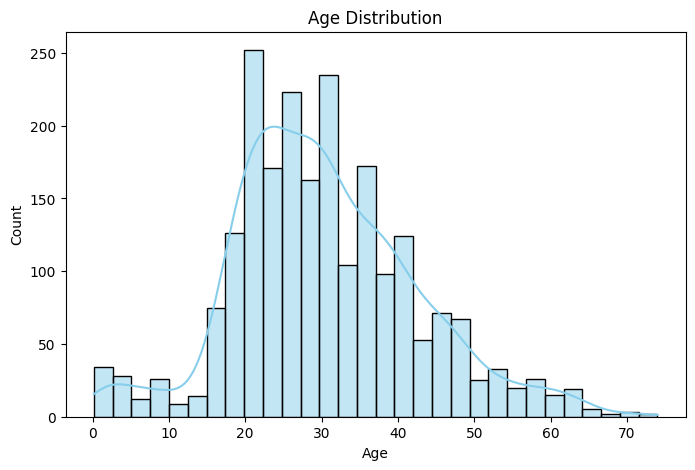

In [42]:
# Age distribution (histogram)
plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True, bins=30, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

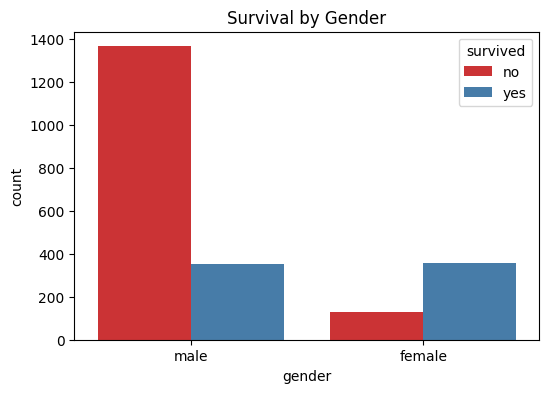

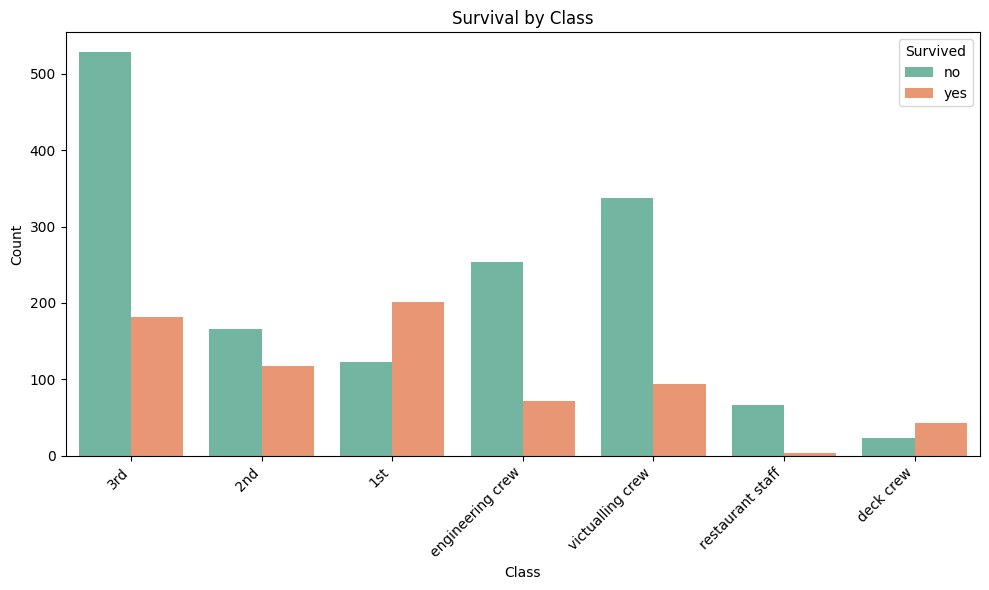

In [30]:
# Survival rate by Gender
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender', hue='survived', palette='Set1')
plt.title('Survival by Gender')
plt.show()

# Survival by Class
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='class', hue='survived', palette='Set2')
plt.title('Survival by Class')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend(title='Survived')
plt.tight_layout()
plt.show()



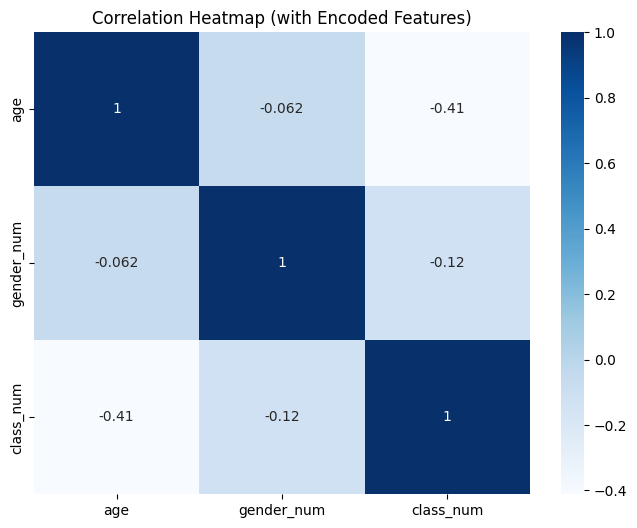

In [29]:
# Encoding categorical features
df['gender_num'] = df['gender'].map({'male': 0, 'female': 1})
df['class_num'] = df['class'].map({'1st': 1, '2nd': 2, '3rd': 3})

# Updated correlation heatmap
plt.figure(figsize=(8,6))
corr = df[['age', 'gender_num', 'class_num']].corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Heatmap (with Encoded Features)')
plt.show()
